# EN3160 Assignment 01

## Intensity Transformations and Neighborhood Filtering

---

**Name:** R.A.C.D. Ranawaka  
**Index Number:** 230526A  


---

### Assignment Objective

This assignment investigates fundamental image processing techniques involving
intensity transformations and neighborhood filtering. The experiments explore
how different image enhancement and filtering techniques affect image
characteristics and visual quality.

# 1. Intensity Transformation

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

image_path = "data/input/emma.jpg"

im = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if im is None:
    raise FileNotFoundError(f"Could not load image: {image_path}")

#### * Implementing the intensity transformation function

In [16]:
def intensity_transform(im, breakpoints):
    
    breakpoints = np.asarray(breakpoints, dtype=np.float32)

    input_values = breakpoints[:, 0]
    output_values = breakpoints[:, 1]

    transformed = np.interp(
        im.astype(np.float32),
        input_values,
        output_values
    )

    transformed = np.clip(transformed, 0, 255)

    return transformed.astype(np.uint8)

#### * Different Breakout Points Configurations

In [48]:
breakpoints_0 = np.array([
    [0,   0],
    [50,  50],
    [50, 100],
    [150, 255],
    [150, 150],
    [255, 255]
])

breakpoints_1 = np.array([
    [0,   0],
    [50,  30],
    [50, 110],
    [150, 255],
    [150, 140],
    [255, 255]
])

breakpoints_2 = np.array([
    [0,   0],
    [50,  40],
    [50, 100],
    [150, 235],
    [150, 160],
    [255, 255]
])

breakpoints_3 = np.array([
    [0,   0],
    [50,  30],
    [50, 80],
    [150, 20],
    [150, 80],
    [255, 50]
])

transformed = intensity_transform(im, breakpoints_3)

#### * Intensity Transformation Plot

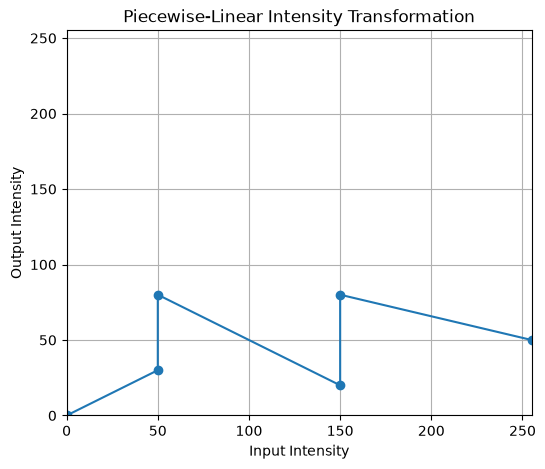

In [49]:
plt.figure(figsize=(6, 5))

plt.plot(
    breakpoints_3[:, 0],
    breakpoints_3[:, 1],
    marker="o"
)

plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.title("Piecewise-Linear Intensity Transformation")

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.grid(True)
plt.show()

#### * Comparison between original image and transformed image

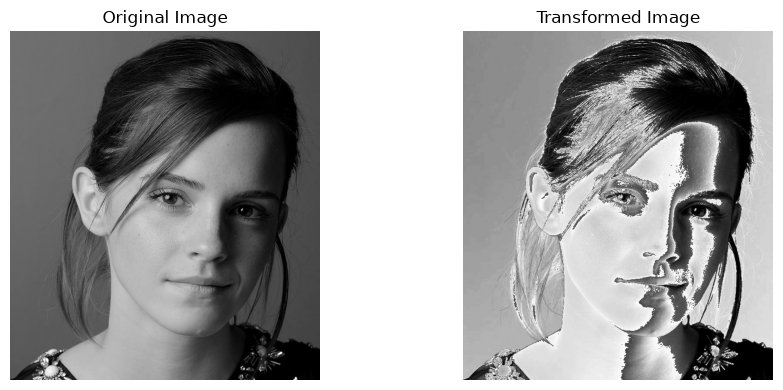

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(im, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(transformed, cmap="gray")
axes[1].set_title("Transformed Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()